<a href="https://colab.research.google.com/github/JNario31/LinearModels/blob/main/SupportVectorMachinesVisualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

bc = datasets.load_breast_cancer()

X = bc.data[:,:2]  # only use first two feature for visualization purpoese
y = bc.target

print(X.shape)
print(y.shape)

# normalize the dataset (zero mean and unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# split data into a training set and a test set
# test set is 30% of the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=2)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(569, 2)
(569,)
(398, 2) (398,)
(171, 2) (171,)


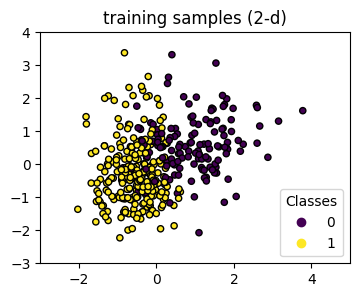

In [2]:
# plot training samples in a 2D plane
#
fig, ax = plt.subplots(figsize=(4, 3))
x_min, x_max, y_min, y_max = -3, 5, -3, 4
ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max))

# Plot samples by color and add legend
# Plot first feature on x axis, second feature on y axis
# Color the points based on their label
scatter = ax.scatter(X_train[:, 0], X_train[:, 1], s=20, c=y_train, label=y_train, edgecolors="k")
ax.legend(*scatter.legend_elements(), loc="lower right", title="Classes")
ax.set_title("training samples (2-d)")
_ = plt.show()

In [3]:
# the function to plot decision boundaries for a SVM binary classifier

from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay

def plot_training_data_with_decision_boundary(
    clf, X, y, fig_title, support_vectors=True
):

    _, ax = plt.subplots(figsize=(4, 3))
    x_min, x_max, y_min, y_max = -3, 5, -3, 4
    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max))

    # Plot decision boundary and margins
    common_params = {"estimator": clf, "X": X, "ax": ax}
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="predict",
        plot_method="pcolormesh",
        alpha=0.3,
    )
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],
        colors=["k", "k", "k"],
        linestyles=["--", "-", "--"],
    )

    if support_vectors:
        # Plot bigger circles around samples that serve as support vectors
        ax.scatter(
            clf.support_vectors_[:, 0],
            clf.support_vectors_[:, 1],
            s=150,
            facecolors="none",
            edgecolors="k",
        )

    # Plot samples by color and add legend
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolors="k")
    ax.legend(*scatter.legend_elements(), loc="lower right", title="Classes")
    # if long_title:
    #     ax.set_title(f" Decision boundaries of SVM")
    # else:
    #     ax.set_title(kernel)
    ax.set_title(fig_title)

    if ax is None:
        plt.show()

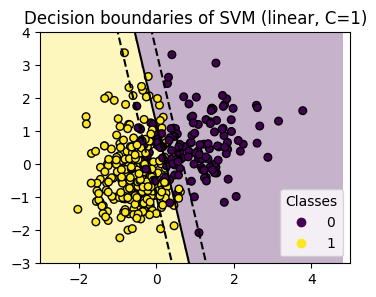

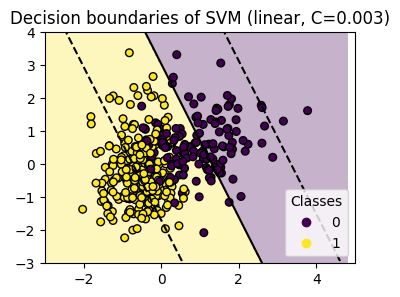

In [4]:
# display the decision boundaries for linear SVM with various C values

clf = svm.SVC(kernel="linear", C=1).fit(X_train, y_train)

plot_training_data_with_decision_boundary(clf, X_train, y_train, "Decision boundaries of SVM (linear, C=1)", support_vectors=False)

clf = svm.SVC(kernel="linear", C=0.003).fit(X_train, y_train)

plot_training_data_with_decision_boundary(clf, X_train, y_train, "Decision boundaries of SVM (linear, C=0.003)", support_vectors=False)

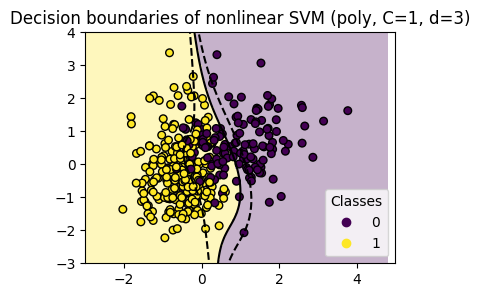

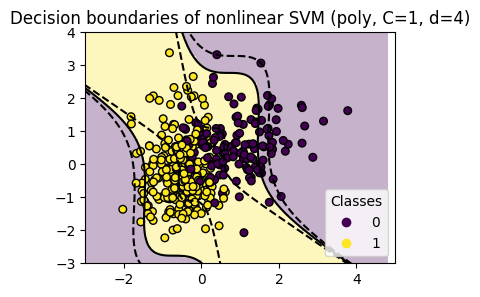

In [5]:
# display the decision boundaries for nonlinear SVM (polynomial kernel) with various c and p values

clf = svm.SVC(kernel='poly', C=1, degree=3).fit(X_train, y_train)

plot_training_data_with_decision_boundary(clf, X_train, y_train, "Decision boundaries of nonlinear SVM (poly, C=1, d=3)", support_vectors=False)

clf = svm.SVC(kernel='poly', C=1, degree=4).fit(X_train, y_train)

plot_training_data_with_decision_boundary(clf, X_train, y_train, "Decision boundaries of nonlinear SVM (poly, C=1, d=4)", support_vectors=False)


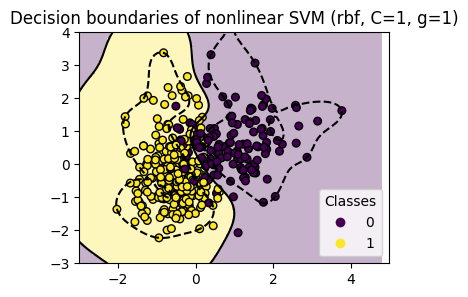

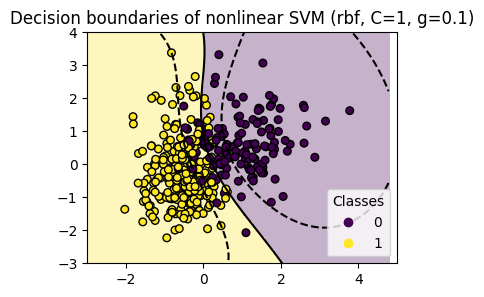

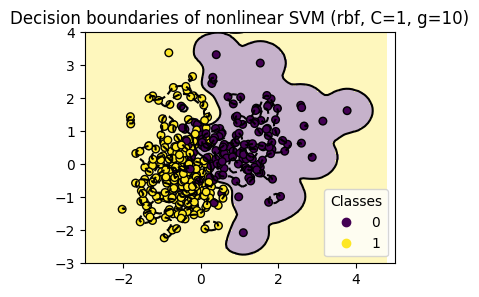

In [6]:
# display the decision boundaries for nonlinear SVM (rbf kernel) with various c and p values

clf = svm.SVC(kernel='rbf', C=1, gamma=1).fit(X_train, y_train)

plot_training_data_with_decision_boundary(clf, X_train, y_train, "Decision boundaries of nonlinear SVM (rbf, C=1, g=1)", support_vectors=False)

clf = svm.SVC(kernel='rbf', C=1, gamma=0.1).fit(X_train, y_train)

plot_training_data_with_decision_boundary(clf, X_train, y_train, "Decision boundaries of nonlinear SVM (rbf, C=1, g=0.1)", support_vectors=False)

clf = svm.SVC(kernel='rbf', C=1, gamma=10).fit(X_train, y_train)

plot_training_data_with_decision_boundary(clf, X_train, y_train, "Decision boundaries of nonlinear SVM (rbf, C=1, g=10)", support_vectors=False)

SVMs are supervised learning algorithms.

Aim to find the optimal hyperplane that separates classes in a feature space.

The optimal hyperplane is defined by maximizing the margin (distance between hyperplane and nearest data points from each class) known as support vectors.

Maximizing the margin helps improve the models generalization to new data.

Support vectors influence the hyperplane's position and orientation.

Kernel trick:
For cases when data is not linearly separable, SVMs use the kernel trick. It maps the data into a higher dimensional space where a linear separator might exist. Common kernels such as RBF, and Poly.

Regularization parameter C:
Balances the trade-off between maximizing the margin and minimizing classification error. Lower C wider margin, higher C focuses on minimizing misclassifications

For RBF: gamma
Higher gamma the effect of a support vector is limited to a smaller region, a more wiggly complex decision boundary. Captures finer details, although risk of overfitting.

For RBF: degree
Is the degree of polynomial, a higher degree means a more complex decision boundary, a degree of 1 is essentially a linear SVM.